# Interpretable pool

`interpretable_pool()` returns 42 pre-configured generator instances, built from 15 of SynForecast's 32 generator classes with one class per behavioral niche. The niches span ARMA and exponential smoothing, long-range memory, volatility clustering, intermittent demand, deterministic chaos, counts, and bounded and heavy-tailed processes.

It is the default corpus behind [`generate_series`](../getting-started/quickstart), and a bias-free starting point for benchmarking or pretraining: generators are allocated proportionally to each niche's behavioral range, so no single domain dominates the pool. The list is ordered round-robin across the niches, so any prefix spans as many distinct behaviors as possible: a `generate_series` panel smaller than the pool still gets one niche per series.

::: {.callout-note}
## What's in, and what's deliberately out

The pool draws from *interpretable, single-mechanism* generators — each slot is one named data-generating process. The meta-generators (`TSIGenerator`, `TCMGenerator`, `KernelSynthGenerator`, `MARGenerator`) are excluded on purpose: they already randomize across many behaviors internally, so folding them in would blur the one-niche-one-mechanism design. Use the [`pretraining_pool()`](#pretraining-pool) preset for maximal breadth in foundation-model pretraining; it bundles those meta-generators, with `interpretable_pool` included by default.
:::

::: {.callout-tip}
## Which pool?

- **`interpretable_pool`** when every series should be one named, interpretable process: benchmarking a method against known mechanisms, stress-testing a pipeline, or building a panel whose behaviours you can name. It is the default behind `generate_series`.
- **`pretraining_pool`** when breadth matters more than interpretability, as in pretraining a foundation model. It contains the whole interpretable pool plus randomised meta-generators; `include_balanced=False` gives a purely procedural corpus.
- **`seasonal_pool`**, added on top of either, when the target data has a strong regular yearly cycle on a moving level: tourism, hospital, or retail demand at quarterly or monthly frequency. `pretraining_pool(include_seasonal=True)` appends it for you. Add it, never substitute it for part of a pool, and skip it for intermittent or weakly seasonal data. The [feature-space coverage](feature_coverage) page shows where it helps and where it does not.
:::


In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast import SynSet, interpretable_pool, pretraining_pool

## Generate a balanced dataset

Create 42 generators and generate one series per generator.

In [ ]:
generators = interpretable_pool(
    min_length=200, max_length=200, freq="D", seed=42, engine="polars"
)
dataset = SynSet(generators)
df = dataset.generate(n_series_per_generator=1)

print(f"Generators: {len(generators)}")
print(f"Series: {df['unique_id'].n_unique()}")
print(f"Total observations: {len(df)}")

Generators: 42
Series: 42
Total observations: 8400


## Generator names

Each generator has a descriptive name indicating its type and configuration.

In [ ]:
for i, gen in enumerate(generators):
    print(f"  {i}: {gen.alias}")

  0: SARIMAGenerator
  1: ETSGenerator
  2: FractionalBrownianMotionGenerator
  3: RegimeSwitchingGenerator
  4: GARCHGenerator
  5: CyclicGenerator
  6: IntermittentDemandGenerator
  7: EnergyLoadGenerator
  8: IoTSensorGenerator
  9: VitalSignsGenerator
  10: GaussianProcessGenerator
  11: ChaoticSystemGenerator
  12: INARGenerator
  13: BoundedProcessGenerator
  14: LevyProcessGenerator
  15: SARIMAGenerator
  16: ETSGenerator
  17: FractionalBrownianMotionGenerator
  18: RegimeSwitchingGenerator
  19: GARCHGenerator
  20: CyclicGenerator
  21: IntermittentDemandGenerator
  22: EnergyLoadGenerator
  23: IoTSensorGenerator
  24: VitalSignsGenerator
  25: GaussianProcessGenerator
  26: ChaoticSystemGenerator
  27: INARGenerator
  28: BoundedProcessGenerator
  29: LevyProcessGenerator
  30: SARIMAGenerator
  31: ETSGenerator
  32: FractionalBrownianMotionGenerator
  33: IntermittentDemandGenerator
  34: IoTSensorGenerator
  35: VitalSignsGenerator
  36: GaussianProcessGenerator
  37: C

## Overview: all 42 series

A compact grid showing every series in the balanced pool.

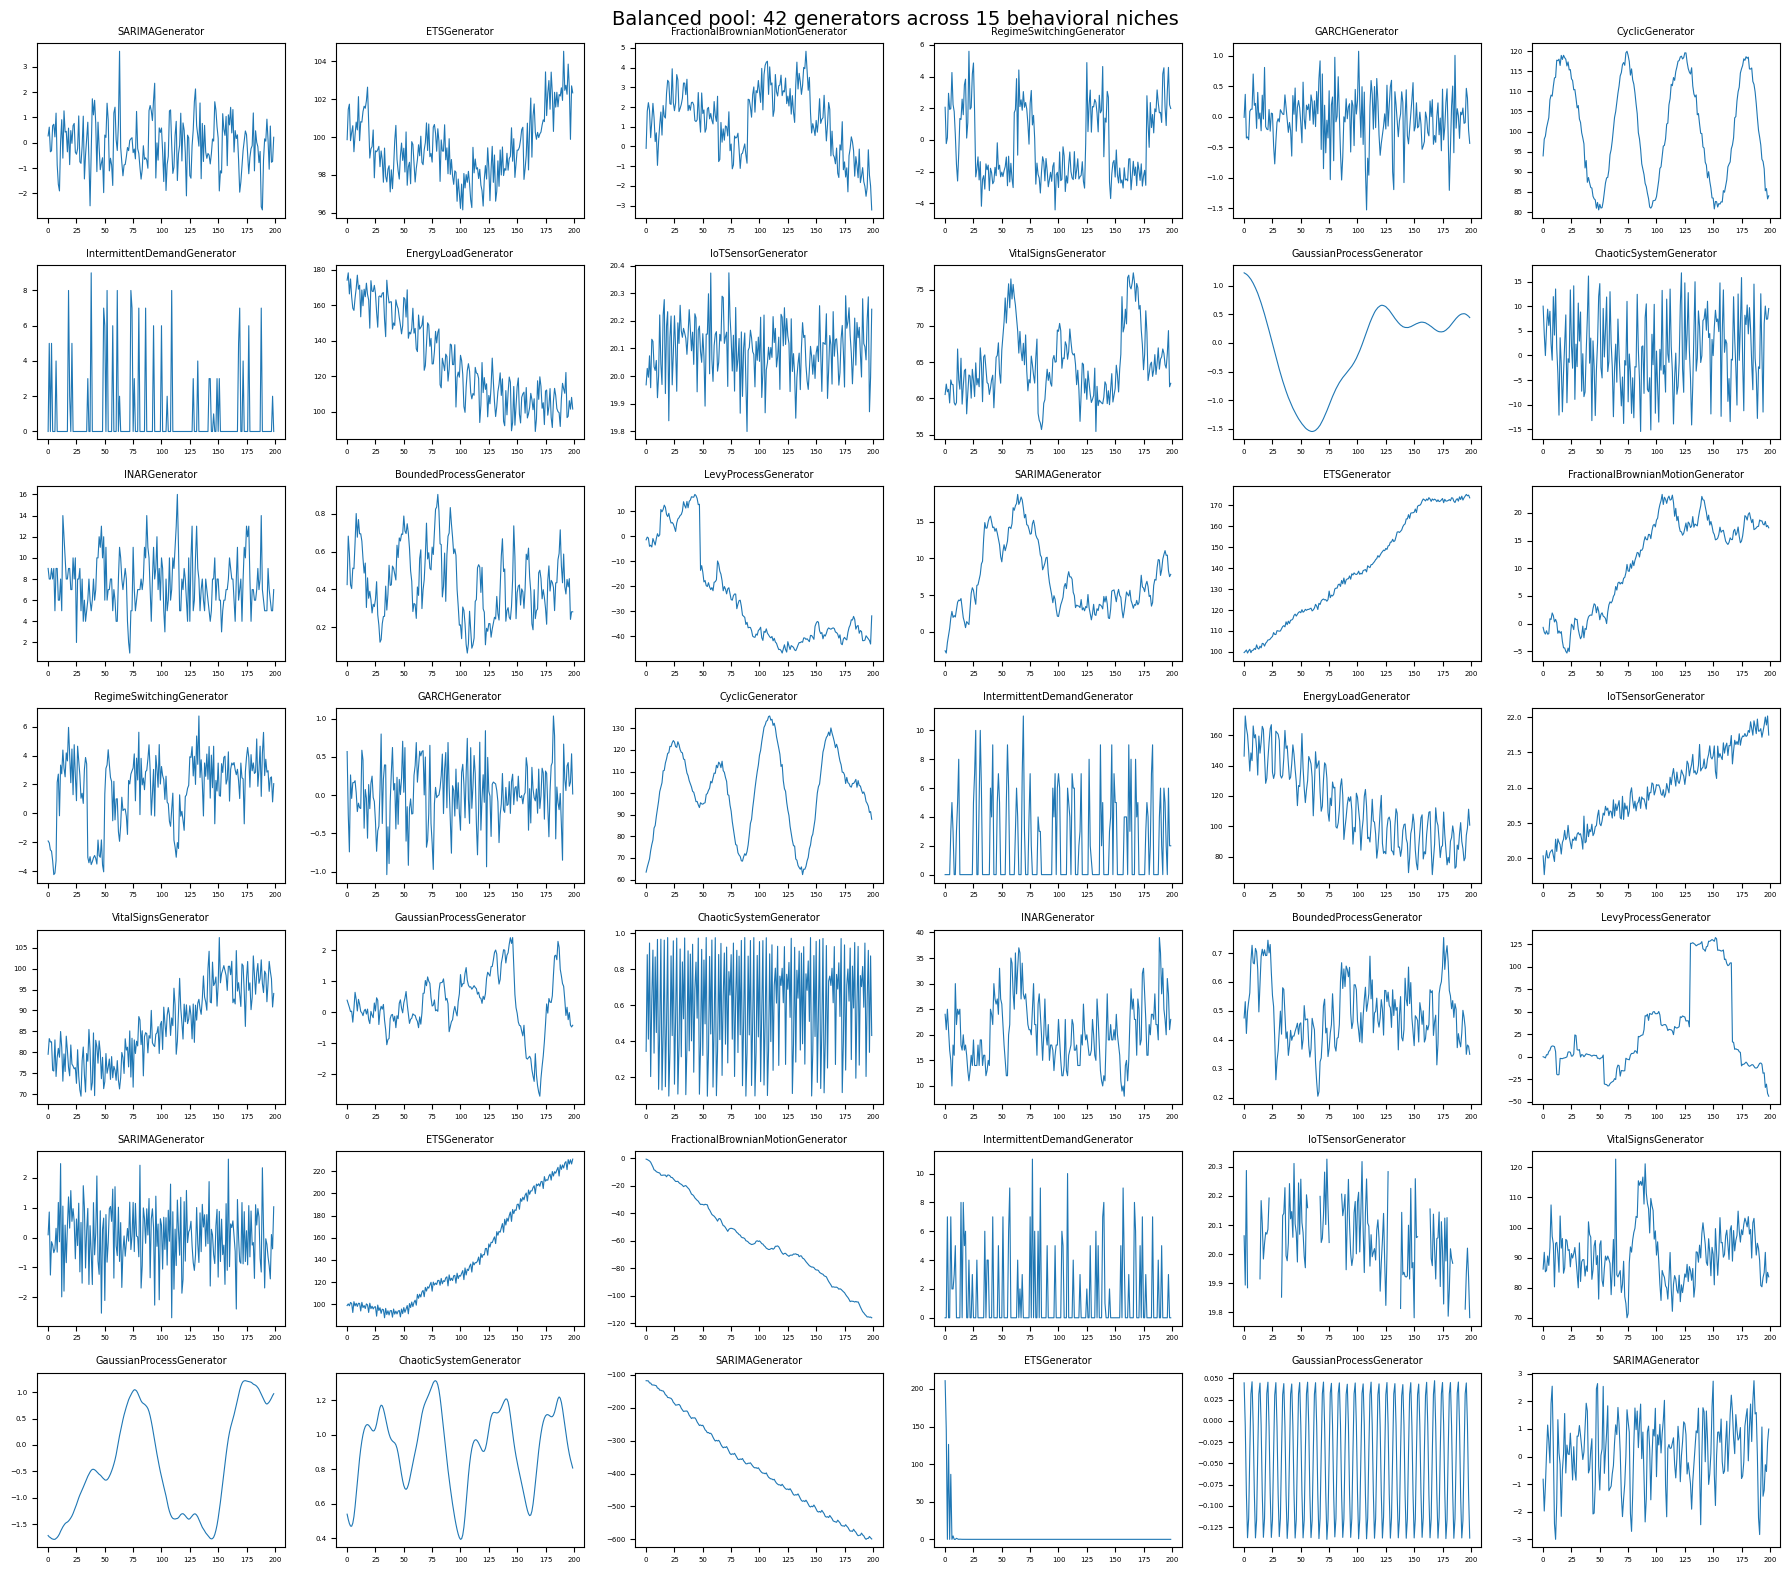

In [ ]:
fig, axes = plt.subplots(7, 6, figsize=(18, 16))
axes = axes.flatten()

for i, gen in enumerate(generators):
    uid = str(i)
    series = df.filter(pl.col("unique_id") == uid)
    values = series["y"].to_list()
    axes[i].plot(values, linewidth=0.8)
    axes[i].set_title(gen.alias, fontsize=7)
    axes[i].tick_params(labelsize=5)

fig.suptitle("Balanced pool: 42 generators across 15 behavioral niches", fontsize=14)
plt.tight_layout()
plt.show()

## Niche deep-dives

Each behavioral niche contributes a different number of generators. Below we group them by niche and plot the variants side by side.

In [ ]:
niche_labels = [
    ("ARMA + Seasonality (SARIMA)", "SARIMAGenerator"),
    ("Exponential Smoothing (ETS)", "ETSGenerator"),
    ("Long-Range Memory (FBM)", "FractionalBrownianMotionGenerator"),
    ("Structural Breaks (Regime Switching)", "RegimeSwitchingGenerator"),
    ("Volatility Clustering (GARCH)", "GARCHGenerator"),
    ("Irregular Cycles (Cyclic)", "CyclicGenerator"),
    ("Sparse/Intermittent (Intermittent Demand)", "IntermittentDemandGenerator"),
    ("Multi-Seasonal (Energy Load)", "EnergyLoadGenerator"),
    ("Sensor Artifacts (IoT Sensor)", "IoTSensorGenerator"),
    ("Physiological (Vital Signs)", "VitalSignsGenerator"),
    ("Smooth/Rough Functions (Gaussian Process)", "GaussianProcessGenerator"),
    ("Deterministic Chaos (Chaotic System)", "ChaoticSystemGenerator"),
    ("Count Time Series (INAR)", "INARGenerator"),
    ("Bounded/Proportion Data (Bounded Process)", "BoundedProcessGenerator"),
    ("Heavy-Tailed Processes (Levy Process)", "LevyProcessGenerator"),
]

# The pool is interleaved across niches, so look indices up by class
# rather than assuming contiguous blocks.
niches = [
    (label, [i for i, g in enumerate(generators) if type(g).__name__ == cls])
    for label, cls in niche_labels
]

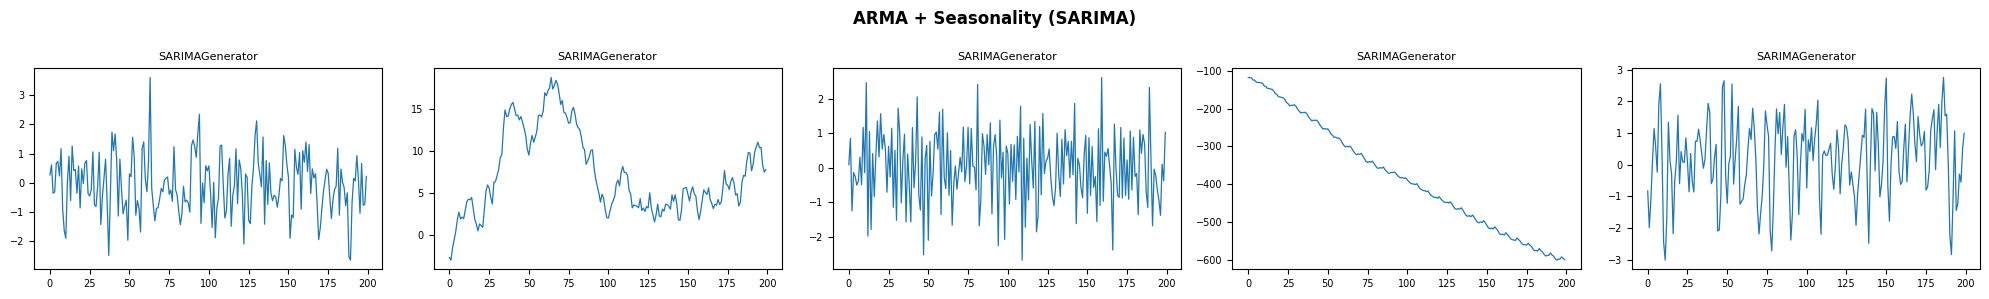

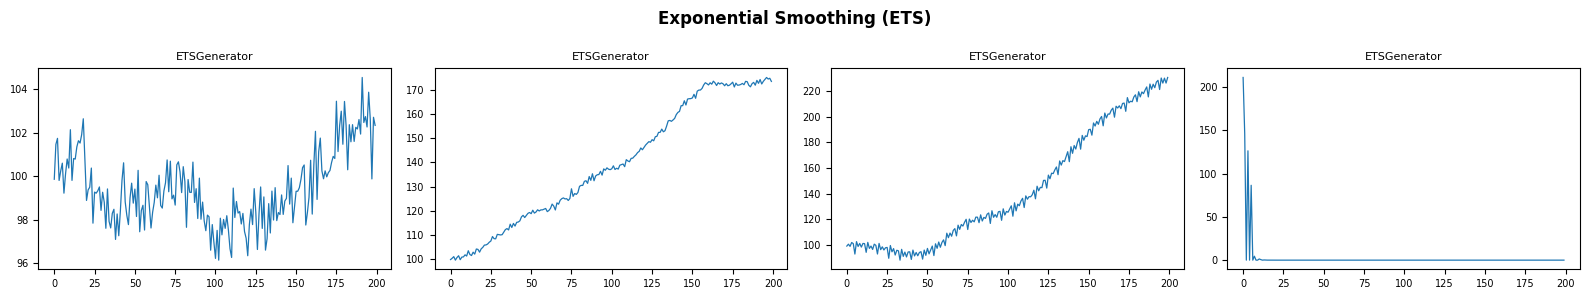

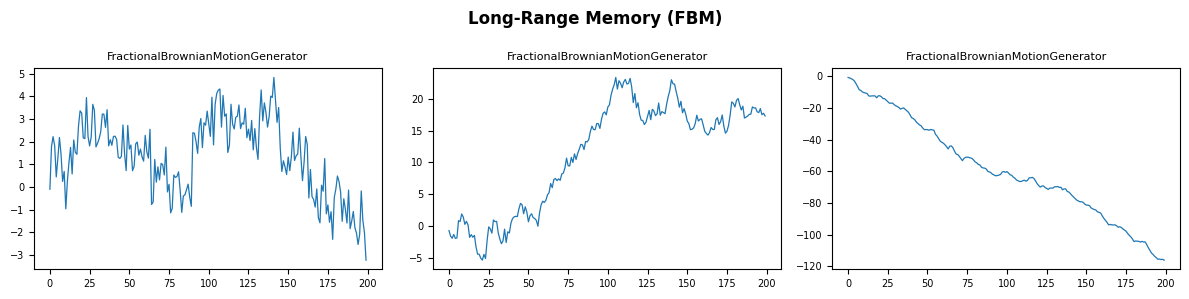

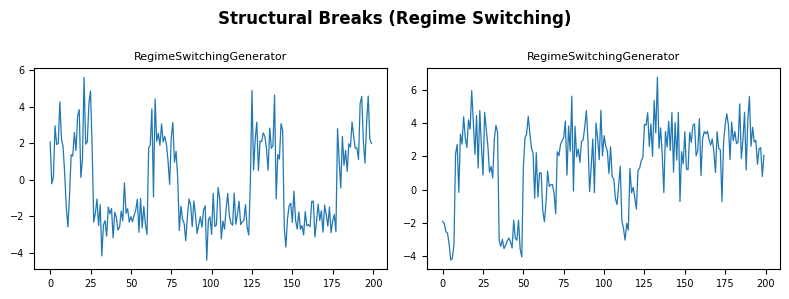

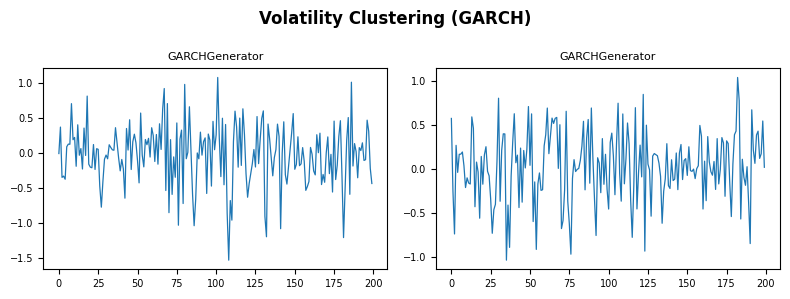

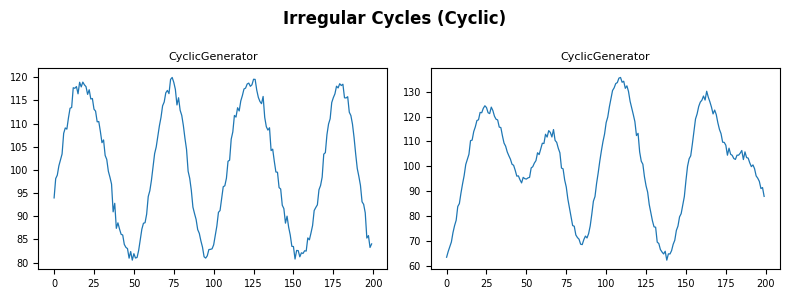

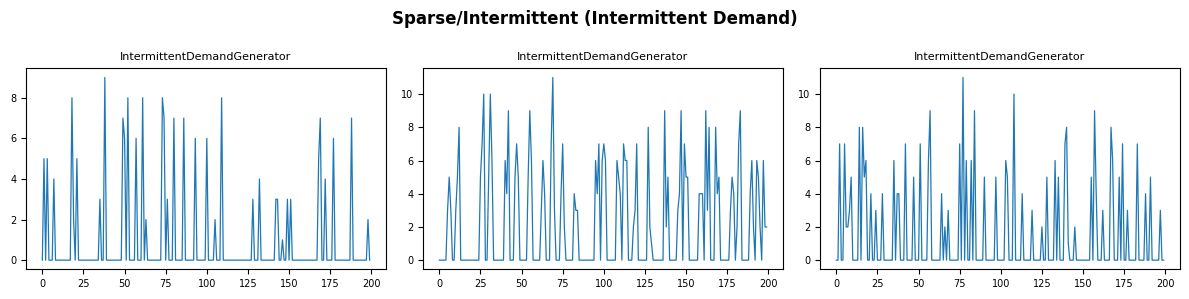

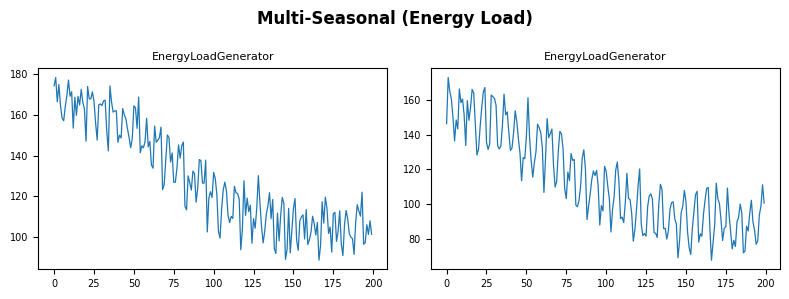

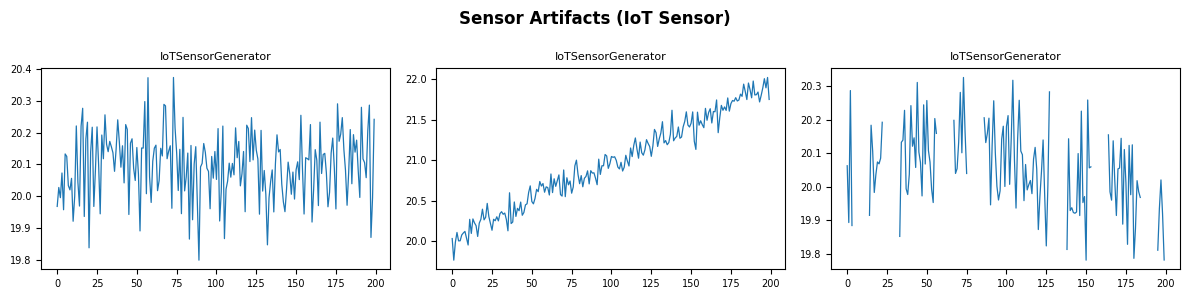

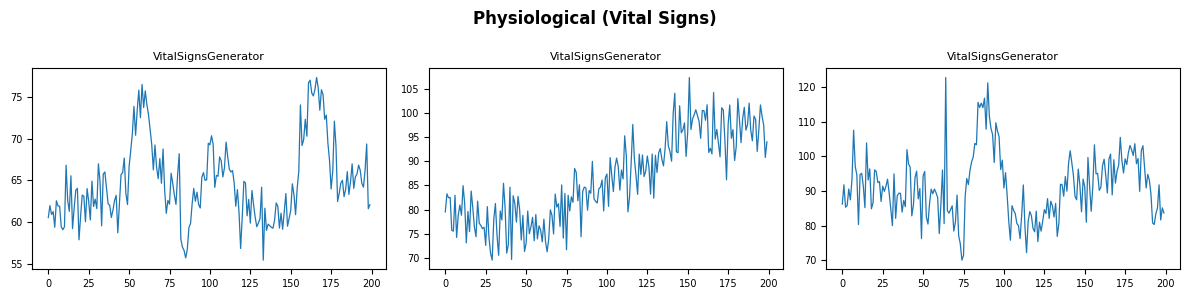

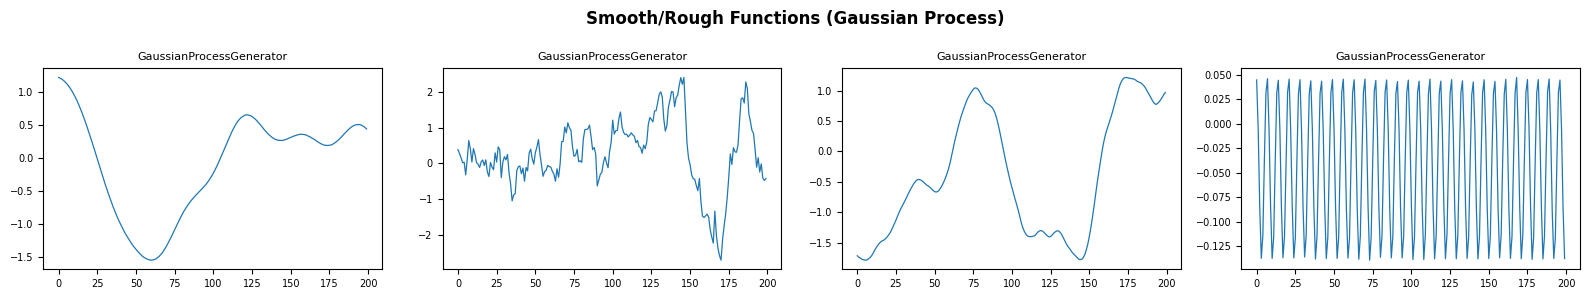

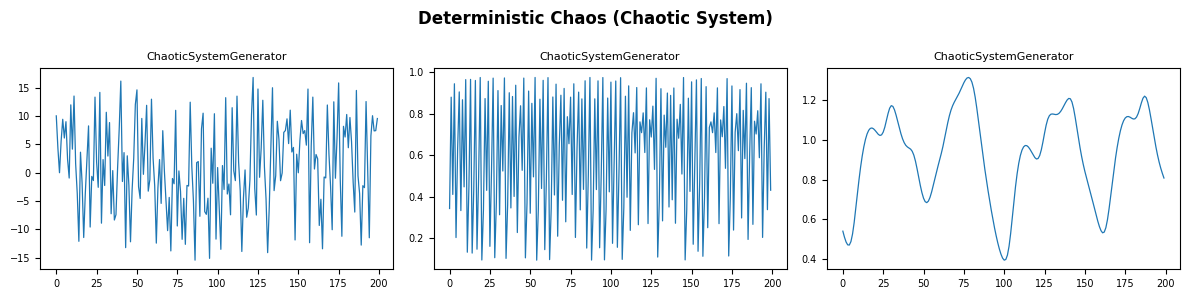

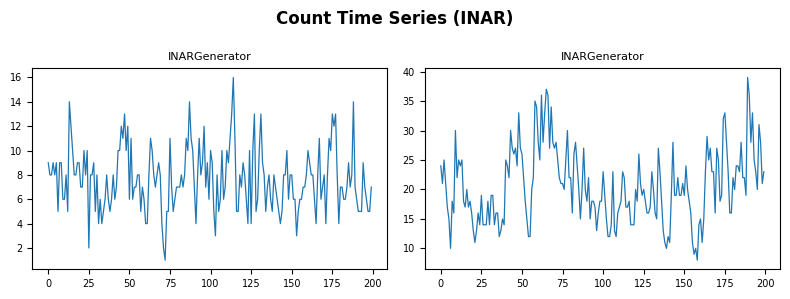

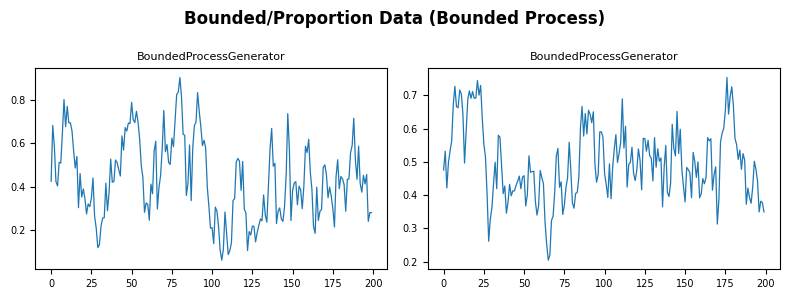

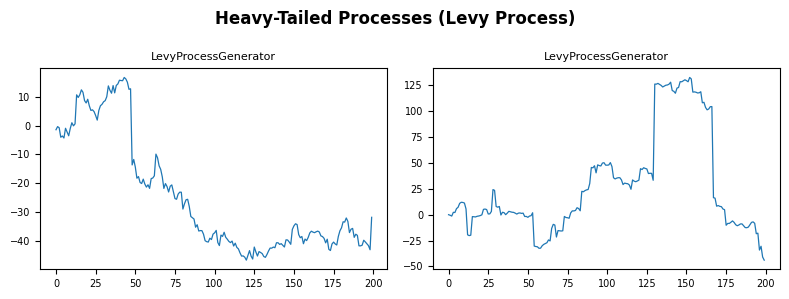

In [ ]:
for niche_name, indices in niches:
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), squeeze=False)
    fig.suptitle(niche_name, fontsize=12, fontweight="bold")

    for j, idx in enumerate(indices):
        uid = str(idx)
        series = df.filter(pl.col("unique_id") == uid)
        axes[0][j].plot(series["y"].to_list(), linewidth=0.9)
        axes[0][j].set_title(generators[idx].alias, fontsize=8)
        axes[0][j].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

## Summary statistics

Compare key statistics across all 42 series to see how the balanced pool spans different value ranges and variabilities.

In [ ]:
stats = (
    df.group_by("unique_id")
    .agg(
        [
            pl.col("y").count().alias("count"),
            pl.col("y").min().alias("min"),
            pl.col("y").max().alias("max"),
            pl.col("y").mean().alias("mean"),
            pl.col("y").std().alias("std"),
        ]
    )
    .sort("unique_id")
)
stats

unique_id,count,min,max,mean,std
cat,u32,f64,f64,f64,f64
"""0""",200,-2.652759,3.609343,-0.068571,0.99059
"""1""",200,96.138073,104.540914,99.457374,1.680738
"""10""",200,-1.549691,1.22711,-0.083459,0.761829
"""11""",200,-15.4612,16.7784,0.983599,7.871835
"""12""",200,1.0,16.0,7.64,2.544163
…,…,…,…,…,…
"""5""",200,80.533159,119.965854,101.125541,12.976649
"""6""",200,0.0,9.0,0.915,2.168244
"""7""",200,88.836529,178.20318,129.009721,25.104989


## Scaling up

Generate multiple series per generator for a larger dataset.

In [ ]:
df_large = dataset.generate(n_series_per_generator=5)
print(f"Series: {df_large['unique_id'].n_unique()}")
print(f"Total observations: {len(df_large)}")

Series: 210
Total observations: 42000


Plot five series from a single generator to see intra-generator variation.

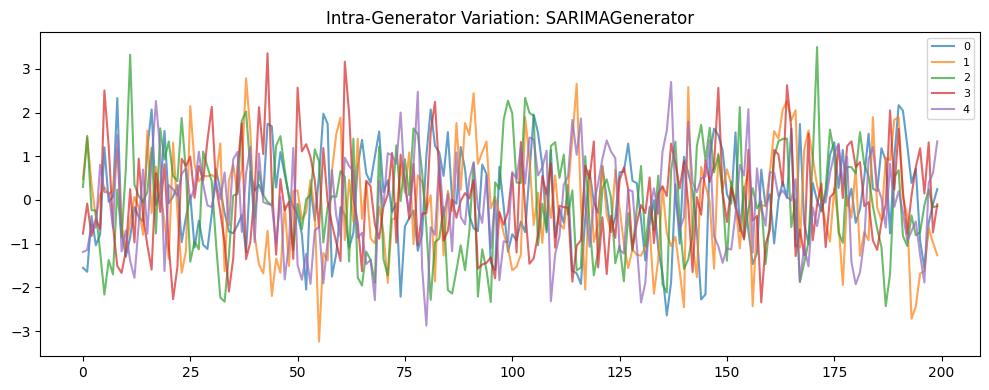

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

# SynSet assigns ids per generator in pool order, so series 0-4 come
# from generators[0]: the SARIMAGenerator configured as a stationary AR(1)
for sid in range(5):
    uid = str(sid)
    series = df_large.filter(pl.col("unique_id") == uid)
    ax.plot(series["y"].to_list(), alpha=0.7, label=uid)

ax.set_title(f"Intra-Generator Variation: {generators[0].alias}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Pretraining pool

`pretraining_pool()` is the breadth-maximizing counterpart to `interpretable_pool()`. It keeps the 42 single-mechanism instances above and adds independently-seeded copies of the four meta-generators `interpretable_pool` deliberately leaves out — `TSIGenerator`, `TCMGenerator`, `KernelSynthGenerator`, and `MARGenerator`. Each of those resamples a fresh trend/seasonal, causal-graph, GP-kernel, or mixture-autoregressive configuration per series, so a handful of instances already spans a very wide distribution — the goal when pretraining a foundation model rather than benchmarking one named process. The default length range is wider too (256-1024 steps), matching typical pretraining contexts.

Two knobs control the mix: `n_meta_variants` sets how many independently-seeded copies of each meta-generator to add (default 3), and `include_balanced=False` drops the single-mechanism generators for a purely procedural corpus.

In [ ]:
pretrain = pretraining_pool(
    min_length=256, max_length=256, freq="D", seed=42, engine="polars"
)
meta_only = pretraining_pool(include_balanced=False, engine="polars")

from collections import Counter

print(f"pretraining_pool: {len(pretrain)} generators")
print(f"  {len(pretrain) - len(meta_only)} single-mechanism (from interpretable_pool)")
print(f"  {len(meta_only)} meta-generator instances")
print("  meta-generators:", dict(Counter(type(g).__name__ for g in meta_only)))

pretraining_pool: 54 generators
  42 single-mechanism (from interpretable_pool)
  12 meta-generator instances
  meta-generators: {'TSIGenerator': 3, 'TCMGenerator': 3, 'KernelSynthGenerator': 3, 'MARGenerator': 3}


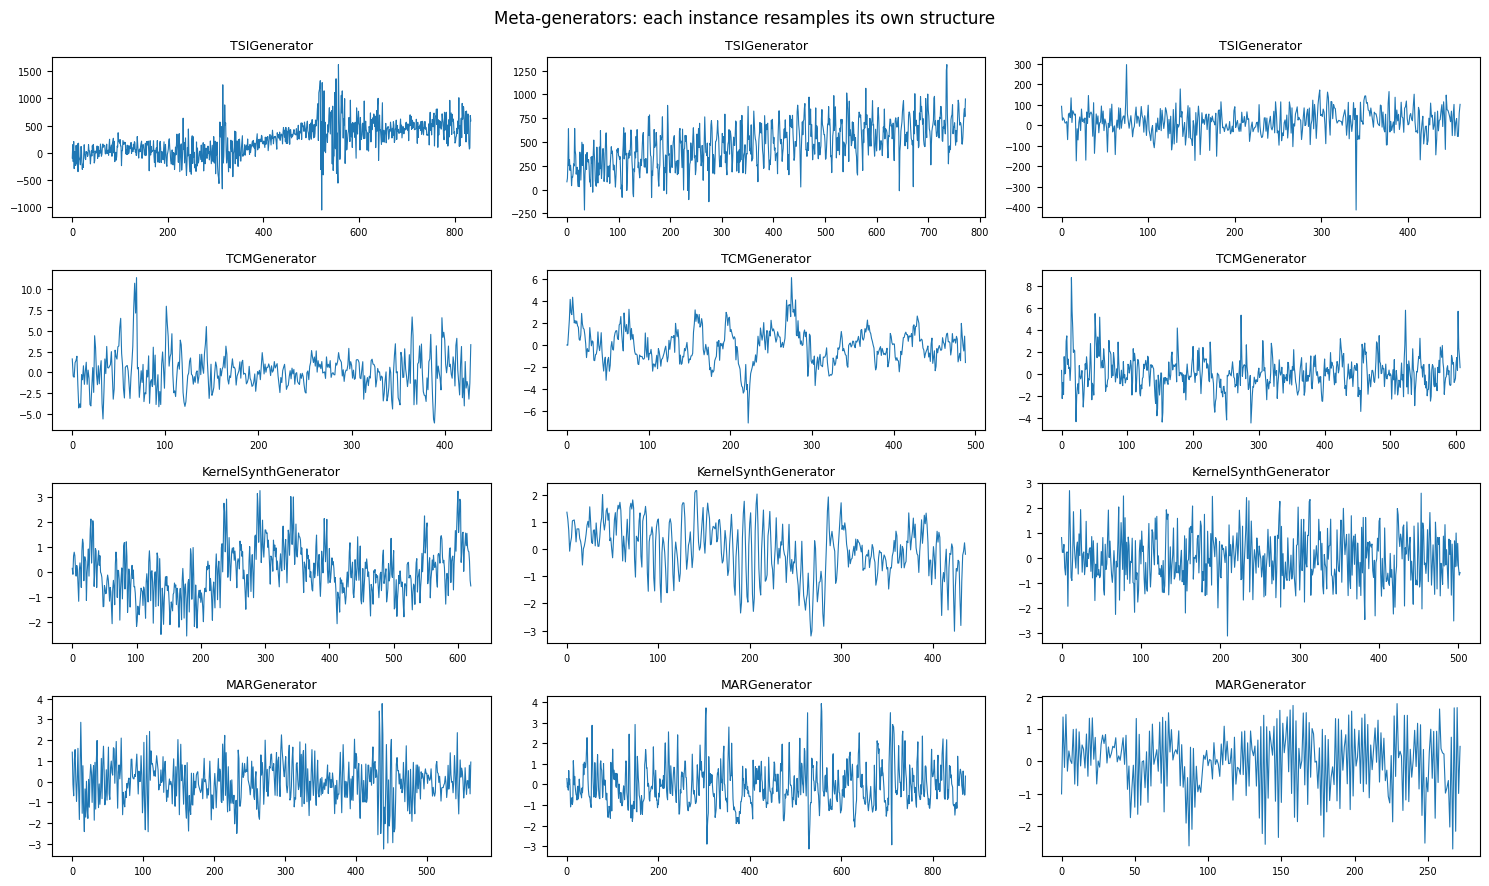

In [ ]:
# Each meta-generator instance draws its own structure, so even twelve series
# span trends, seasonality, causal dynamics, kernel-sampled shapes, and
# mixture-autoregressive dynamics.
meta_df = SynSet(meta_only).generate(n_series_per_generator=1)

fig, axes = plt.subplots(4, 3, figsize=(15, 9))
for ax, (uid, gen) in zip(axes.ravel(), enumerate(meta_only)):
    series = meta_df.filter(pl.col("unique_id") == str(uid))
    ax.plot(series["y"].to_list(), linewidth=0.8)
    ax.set_title(type(gen).__name__, fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle("Meta-generators: each instance resamples its own structure")
plt.tight_layout()
plt.show()

## Seasonal pool

`seasonal_pool()` is a small, opt-in addition: eight configured instances of `TSIGenerator`, `ETSGenerator`, and `SeasonalGenerator` with a pronounced seasonal cycle whose swing moves with the level, under moderate to heavy noise, persistent dependence, and occasional level or slope breaks. The period follows `freq` as elsewhere, so `"QS"` gives period 4 and `"MS"` period 12; yearly frequencies raise because there is no cycle to build.

Coverage benchmarks on real quarterly and monthly panels found this region under-represented: real tourism and hospital series had no close synthetic neighbour in either pool. Adding the seasonal pool on top of the interpretable pool raised the share of real series with a close neighbour by 8 to 32 points on tourism, hospital, and M1 monthly panels, was neutral on M4, and gave nothing on intermittent car-parts data, where it cost a few points when it displaced the pretraining pool's share instead of being added. Its effect on forecasting accuracy has not been measured, which is why it is not part of any default.


In [ ]:
from synforecast import SynSet, interpretable_pool, seasonal_pool

pool = interpretable_pool(min_length=96, max_length=96, freq="MS", engine="polars")
pool += seasonal_pool(min_length=96, max_length=96, freq="MS", engine="polars")
df = SynSet(pool).generate(n_series_per_generator=1, n_jobs=1)
print(f"{len(pool)} generators, {df['unique_id'].n_unique()} series")


50 generators, 50 series


Whether pretraining on a synthetic corpus like this actually helps depends on the target data and the amount of real history available. See [when synthetic data helps](when_synthetic_helps) for a paired, multi-seed benchmark that reports where it wins, where it is neutral, and where the edge reverses.